In [1]:
import os
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from typing import List

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform, randint

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
churn_df = pd.read_csv("archive.zip")
churn_df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


# Exploratory Data Analysis(EDA)

In [3]:
print(f"The Numbers of Rows and Columns in this data set are: \
{churn_df.shape[0]} rows and {churn_df.shape[1]} columns.")

The Numbers of Rows and Columns in this data set are: 7043 rows and 21 columns.


In [4]:
# colors
NAVY = "#1E2761"
ACCENT = "#4B9FE1"
ICE_BLUE = "#CADCFC"
LIGHT_BG = "#F4F7FC"
LIGHT_GRAY = "#E2E8F0"
MID_GRAY = "#64748B"
DARK_TEXT = "#1E293B" 
GREEN = "#22C55E"
ORANGE = "#F97316"
RED = "#EF4444"
TEAL = "#0D9488"
PURPLE = "#7C3AED"
WHITE = "#FFFFFF"
SOFT_BLUE = "#7B94E8"
DEEP_BLUE = "#2B3A8E"

In [5]:
#lowercasing all the column names
churn_df.columns = churn_df.columns.str.lower()

In [6]:
#Checking for Data type of columns
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [7]:
# based on observation changing totalcharges to float64
churn_df["totalcharges"] = pd.to_numeric(churn_df["totalcharges"], errors="coerce")

In [8]:
#duplicates
print(f"Duplicate Rows: {churn_df.duplicated().sum()}")

Duplicate Rows: 0


In [9]:
#missing percentage
missing_pct = (churn_df.isnull().sum() / len(churn_df) * 100).round(2) 
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)
quality_score = round((1 - churn_df.isnull().any(axis=1).sum() / len(churn_df)) * 100, 1)

print(f"Quality Score - {quality_score} \nMissing % - \n {missing_pct}.")

Quality Score - 99.8 
Missing % - 
 totalcharges    0.16
dtype: float64.


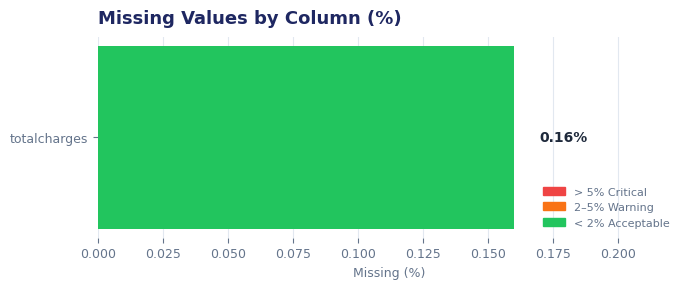

In [10]:
def bar_color(v):
    if v > 5:   
        return RED   #critical
    elif v > 2: 
        return ORANGE   #warning
    elif v > 0:     
        return GREEN   #acceptable
    else:
        return MID_GRAY # Zero bar

if not missing_pct.empty:
    colors = [bar_color(v) for v in missing_pct.values]
fig, ax = plt.subplots(figsize=(7, 3))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, height=0.4, edgecolor="none", zorder=3)

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val}%", va="center", fontsize=10, fontweight="bold", color=DARK_TEXT)

ax.set_xlabel("Missing (%)", fontsize=9, color=MID_GRAY)
ax.set_title("Missing Values by Column (%)", fontsize=13, fontweight="bold", color=NAVY, loc="left", pad=10)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="x", color=LIGHT_GRAY, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(colors=MID_GRAY, labelsize=9)
ax.set_xlim(0, missing_pct.max() * 1.4)
patches = [
    mpatches.Patch(color=RED, label="> 5% Critical"),
    mpatches.Patch(color=ORANGE, label="2–5% Warning"),
    mpatches.Patch(color=GREEN, label="< 2% Acceptable"),
]
ax.legend(handles=patches, loc="lower right", frameon=False, fontsize=8, labelcolor=MID_GRAY)

plt.tight_layout()
plt.savefig("charts/01_data_quality_bar.png", dpi=300, bbox_inches="tight", facecolor=WHITE)


In [11]:
#removing null for eda
def handle_nulls(df, threshold=0.05):
    df = df.loc[:, df.isna().mean() < threshold]
    df = df.dropna().reset_index(drop=True)
    return df

In [12]:
eda_churn_df = churn_df.copy()
eda_churn_df = handle_nulls(eda_churn_df)
eda_churn_df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [13]:
eda_churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   seniorcitizen     7032 non-null   int64  
 3   partner           7032 non-null   object 
 4   dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   phoneservice      7032 non-null   object 
 7   multiplelines     7032 non-null   object 
 8   internetservice   7032 non-null   object 
 9   onlinesecurity    7032 non-null   object 
 10  onlinebackup      7032 non-null   object 
 11  deviceprotection  7032 non-null   object 
 12  techsupport       7032 non-null   object 
 13  streamingtv       7032 non-null   object 
 14  streamingmovies   7032 non-null   object 
 15  contract          7032 non-null   object 
 16  paperlessbilling  7032 non-null   object 


In [14]:
# converting tenure to bins
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]
eda_churn_df['tenure_group'] = pd.cut(eda_churn_df.tenure, range(1, 80, 12), right=False, labels=labels)

In [15]:
eda_churn_df = eda_churn_df.drop("tenure", axis=1, errors="ignore")
eda_churn_df.head()

,customerid,gender,seniorcitizen,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


In [16]:
# based on observation changing seniorcitizen to object
eda_churn_df["seniorcitizen"] = eda_churn_df["seniorcitizen"].map({1: "Yes", 0: "No"})

In [17]:
#statistics summary
eda_churn_df.describe().T

,count,mean,std,min,25%,50%,75%,max
monthlycharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
totalcharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [18]:
eda_churn_df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn', 'tenure_group'],
      dtype='object')

In [19]:
#unique values of cat
def categorical_unique_values(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    result = []
    
    for col in columns:
        unique_vals = df[col].unique()

        result.append({
            "field": col,
            "values": unique_vals,
            "count": len(unique_vals)
        })
    
    return pd.DataFrame(result)

categorical_unique_values(eda_churn_df, ['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'churn', 'tenure_group'])

,field,values,count
0,gender,"[Female, Male]",2
1,seniorcitizen,"[No, Yes]",2
2,partner,"[Yes, No]",2
3,dependents,"[No, Yes]",2
4,phoneservice,"[No, Yes]",2
5,multiplelines,"[No phone service, No, Yes]",3
6,internetservice,"[DSL, Fiber optic, No]",3
7,onlinesecurity,"[No, Yes, No internet service]",3
8,onlinebackup,"[Yes, No, No internet service]",3
9,deviceprotection,"[No, Yes, No internet service]",3


In [20]:
def base_style(ax, title: str = None, xlabel: str = None, ylabel: str = None, grid_axis: str = "y"):
    ax.set_facecolor(WHITE)
    ax.figure.patch.set_facecolor(WHITE)
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", color=NAVY, pad=14, loc="left")
    ax.set_xlabel(xlabel, fontsize=10, color=MID_GRAY, labelpad=6)
    ax.set_ylabel(ylabel, fontsize=10, color=MID_GRAY, labelpad=6)
    ax.tick_params(colors=MID_GRAY, labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color=LIGHT_GRAY, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

def save(name: str, show: bool, folder: str = "charts",):
    os.makedirs(folder, exist_ok=True)
    plt.tight_layout()
    plt.savefig(f"{folder}/{name}.png", dpi=180, bbox_inches="tight", facecolor=WHITE)
    if show:
        plt.show()
    plt.close()
    print(f"Saved Chart to - {folder}/{name}.png")

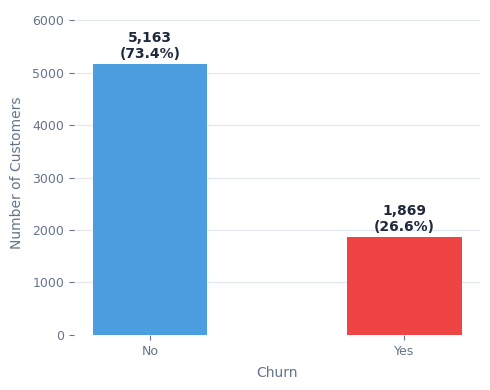

Saved Chart to - charts/02_churn_distribution.png


In [21]:
#Overall Churn Distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts = eda_churn_df["churn"].value_counts()
colors = [ACCENT, RED]
bars = ax.bar(counts.index, counts.values, color=colors, width=0.45, zorder=3, edgecolor="none")
for bar, val in zip(bars, counts.values):
    pct = val / len(eda_churn_df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold", color=DARK_TEXT)
base_style(ax, title="", xlabel="Churn", ylabel="Number of Customers")
ax.set_ylim(0, counts.max() * 1.2)
save(name = "02_churn_distribution", show = True)

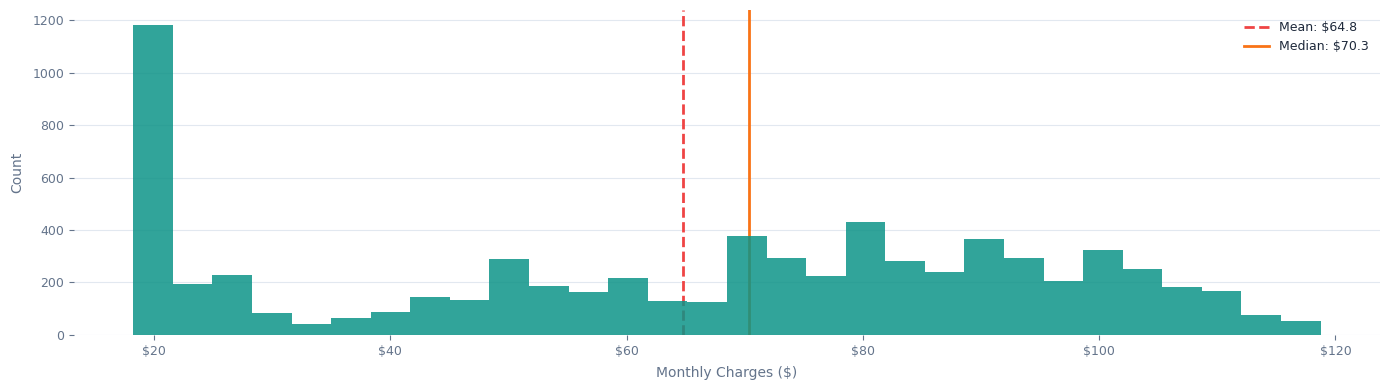

Saved Chart to - charts/03_monthly_charges_distribution.png


In [22]:
# Monthly Charges Distribution
monthly_charges_data = eda_churn_df["monthlycharges"]

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
fig.patch.set_facecolor(WHITE)
ax.hist(monthly_charges_data, bins=30, color=TEAL, edgecolor="none", zorder=3, alpha=0.85)
ax.axvline(monthly_charges_data.mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: ${monthly_charges_data.mean():.1f}")
ax.axvline(monthly_charges_data.median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: ${monthly_charges_data.median():.1f}")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
base_style(ax, title="", xlabel="Monthly Charges ($)",  ylabel="Count")
save(name = "03_monthly_charges_distribution", show = True)

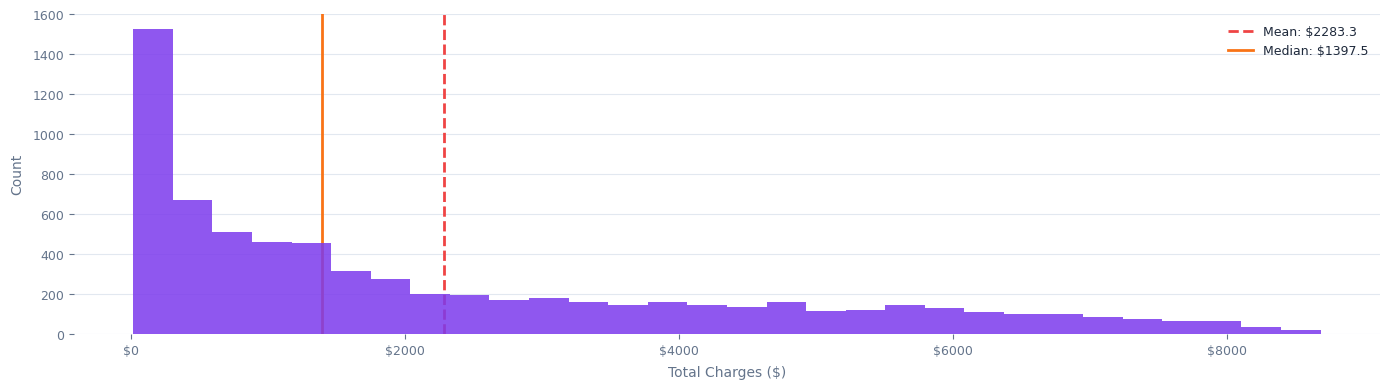

Saved Chart to - charts/04_total_charges_distribution.png


In [23]:
# Total Charges Distribution
total_charge_data = eda_churn_df["totalcharges"]

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
fig.patch.set_facecolor(WHITE)
ax.hist(total_charge_data, bins=30, color=PURPLE, edgecolor="none", zorder=3, alpha=0.85)
ax.axvline(total_charge_data.mean(),   color=RED,    linewidth=2, linestyle="--", label=f"Mean: ${total_charge_data.mean():.1f}")
ax.axvline(total_charge_data.median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: ${total_charge_data.median():.1f}")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
base_style(ax, title="", xlabel="Total Charges ($)", ylabel="Count")
save(name = "04_total_charges_distribution", show = True)

In [24]:
#Numerical Variables outliers
#going to use IQR Method as for Z-score the data is not Gaussian from above graph

for col in ["monthlycharges", "totalcharges"]:
    Q1 = eda_churn_df[col].quantile(0.25)
    Q3 = eda_churn_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = eda_churn_df[(eda_churn_df[col] < lower) | (eda_churn_df[col] > upper)]
    print(f"Outliers: {len(outliers)} rows. ", 
          f"({len(outliers)/len(eda_churn_df)*100:.2f}%)")

#Categorical Variables outliers
#from above categorical_unique_values fn we can say that we don't any outliers (if we consider "No internet service" as valid).

Outliers: 0 rows.  (0.00%)
Outliers: 0 rows.  (0.00%)


## Univariate Analysis

In [25]:
# For categorical columns - check churn rate difference
result_uni = []
for col in eda_churn_df.select_dtypes(include={"object", "category"}).columns:
    if col == "churn" or col == "customerid":
        continue
    
    churn_rate = eda_churn_df.groupby(col, observed=True)["churn"].apply(lambda x: (x=="Yes").mean() * 100).round(1).sort_values(ascending=False)
    diff = churn_rate.max() - churn_rate.min()
    result_uni.append(
        {
            "Field": col,
            "Max Diff": diff,
            "Churn Rate": churn_rate.to_dict()
        })
result_uni_df = pd.DataFrame(result_uni)

# > 20% -  Must include (strong relationship with churn)
# 10–20% Should include (moderate relationship)
# < 10% Skip (weak relationship)

result_uni_df.sort_values("Max Diff", ascending= False)

,Field,Max Diff,Churn Rate
16,tenure_group,41.1,"{'1 - 12': 47.7, '13 - 24': 28.7, '25 - 36': 2..."
13,contract,39.9,"{'Month-to-month': 42.7, 'One year': 11.3, 'Tw..."
6,internetservice,34.5,"{'Fiber optic': 41.9, 'DSL': 19.0, 'No': 7.4}"
7,onlinesecurity,34.4,"{'No': 41.8, 'Yes': 14.6, 'No internet service..."
10,techsupport,34.2,"{'No': 41.6, 'Yes': 15.2, 'No internet service..."
8,onlinebackup,32.5,"{'No': 39.9, 'Yes': 21.6, 'No internet service..."
9,deviceprotection,31.7,"{'No': 39.1, 'Yes': 22.5, 'No internet service..."
15,paymentmethod,30.0,"{'Electronic check': 45.3, 'Mailed check': 19...."
12,streamingmovies,26.3,"{'No': 33.7, 'Yes': 30.0, 'No internet service..."
11,streamingtv,26.1,"{'No': 33.5, 'Yes': 30.1, 'No internet service..."


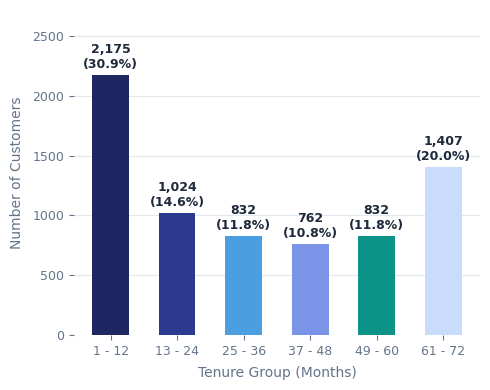

Saved Chart to - charts/05_dist_tenure_group.png


In [26]:
#Customer Distribution by Tenure Group
fig, ax = plt.subplots(figsize=(5, 4))
tenure_counts = eda_churn_df["tenure_group"].value_counts().sort_index()
colors_contract = [NAVY, DEEP_BLUE, ACCENT, SOFT_BLUE, TEAL, ICE_BLUE]

bars = ax.bar(tenure_counts.index, tenure_counts.values, color=colors_contract, width=0.55, zorder=3, edgecolor="none")
for bar, val in zip(bars, tenure_counts.values):
    pct = val / len(eda_churn_df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30, f"{val:,}\n({pct:.1f}%)",ha="center", va="bottom", fontsize=9, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Tenure Group (Months)",ylabel="Number of Customers")
ax.set_ylim(0, tenure_counts.max() * 1.25)

save(name="05_dist_tenure_group", show=True)

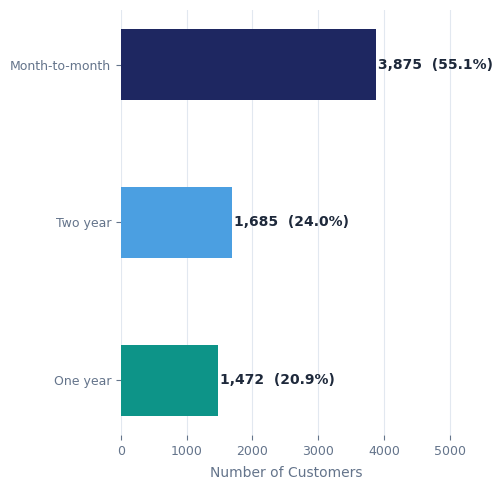

Saved Chart to - charts/06_dist_contract_type.png


In [27]:
#Customer Distribution by Contract Type
fig, ax = plt.subplots(figsize=(5, 5))

contract_counts = eda_churn_df["contract"].value_counts().sort_values(ascending=True)
colors_contract = [TEAL, ACCENT, NAVY]

bars = ax.barh(contract_counts.index, contract_counts.values, color=colors_contract, height=0.45, zorder=3, edgecolor="none")

for bar, val in zip(bars, contract_counts.values):
    pct = val / len(eda_churn_df) * 100
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2, f"{val:,}  ({pct:.1f}%)", va="center", fontsize=10, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Number of Customers", ylabel="", grid_axis="x")
ax.set_xlim(0, contract_counts.max() * 1.3)

save(name="06_dist_contract_type", show=True)

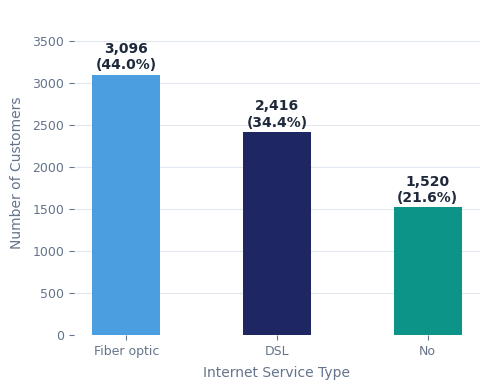

Saved Chart to - charts/07_dist_internet_service.png


In [28]:
#Customer Distribution by Internet Service
fig, ax = plt.subplots(figsize=(5, 4))

inet_counts = eda_churn_df["internetservice"].value_counts().sort_values(ascending=False)
colors_inet = [ACCENT, NAVY, TEAL]

bars = ax.bar(inet_counts.index, inet_counts.values, color=colors_inet, width=0.45, zorder=3, edgecolor="none")

for bar, val in zip(bars, inet_counts.values):
    pct = val / len(eda_churn_df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30, f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Internet Service Type", ylabel="Number of Customers")
ax.set_ylim(0, inet_counts.max() * 1.25)

save(name="07_dist_internet_service", show=True)

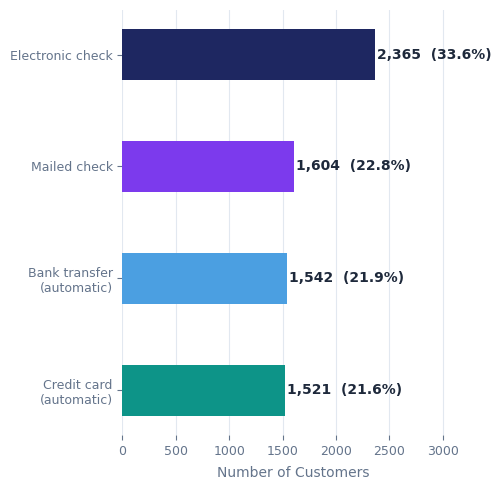

Saved Chart to - charts/08_dist_payment_method.png


In [29]:
#'Electronic check: 45.3 = very high
#Customer Distribution by Payment Method
fig, ax = plt.subplots(figsize=(5,5))

pay_counts = eda_churn_df["paymentmethod"].value_counts().sort_values(ascending=True)

# Shorten long labels
short_labels = [l.replace(" (automatic)", "\n(automatic)") for l in pay_counts.index]
colors_pay = [TEAL, ACCENT, PURPLE, NAVY]

bars = ax.barh(short_labels, pay_counts.values, color=colors_pay, height=0.45, zorder=3, edgecolor="none")

for bar, val in zip(bars, pay_counts.values):
    pct = val / len(eda_churn_df) * 100
    ax.text(val + 20, bar.get_y() + bar.get_height() / 2, f"{val:,}  ({pct:.1f}%)", va="center", fontsize=10, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Number of Customers", ylabel="", grid_axis="x")
ax.set_xlim(0, pay_counts.max() * 1.35)

save(name="08_dist_payment_method", show=True)

## Bivariate Analysis

- Categorical vs Categorical - Bar chart / Stacked bar - Chi-Square Test, Cramer's V Test
- Categorical vs Numerical - Boxplot / Violin plot - T-Test,  Point Biserial (binary category only), ANOVA (cat > 2)
- Numerical vs Numerical - Scatter plot - Correlation, Pearson's R (linear), pearman correlation (for non-linear)

In [30]:
# Categorical vs Categorical - Chi-square test
# all most p_values are zero {Almost all categorical variables are statistically dependent}
# Next adding Cramer's V test
#https://www.researchgate.net/figure/Interpretations-of-Cramers-V-Degree-of-Association_tbl3_344447880
result_bi_cat_vs_cat = []

for col in eda_churn_df.select_dtypes(include={"object", "category"}).columns:
    if col == "churn" or col == "customerid":
        continue

    contingency = pd.crosstab(eda_churn_df[col], eda_churn_df["churn"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n = contingency.values.sum()
    r = contingency.shape[0]
    k = contingency.shape[1]
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

    if cramers_v >= 0.3:
        strength = "Strong"
    elif cramers_v >= 0.15:
        strength = "Moderate"
    elif cramers_v >= 0.05:
        strength = "Weak"
    else:
        strength = "No Relationship"

    result_bi_cat_vs_cat.append(
        {
            "Field": col,
            "P Value": round(p_value, 4),
            "significant": "Yes" if p_value < 0.05 else "No",
            "Cramers V": cramers_v,
            "Strength": strength
                     
        })

result_bi_cat_vs_cat_df = pd.DataFrame(result_bi_cat_vs_cat).sort_values("Cramers V", ascending=False)
result_bi_cat_vs_cat_df

,Field,P Value,significant,Cramers V,Strength
13,contract,0.0000,Yes,0.409560,Strong
16,tenure_group,0.0000,Yes,0.354108,Strong
7,onlinesecurity,0.0000,Yes,0.346992,Strong
10,techsupport,0.0000,Yes,0.342506,Strong
6,internetservice,0.0000,Yes,0.321909,Strong
15,paymentmethod,0.0000,Yes,0.302960,Strong
8,onlinebackup,0.0000,Yes,0.291902,Moderate
9,deviceprotection,0.0000,Yes,0.281159,Moderate
12,streamingmovies,0.0000,Yes,0.230702,Moderate
11,streamingtv,0.0000,Yes,0.230143,Moderate


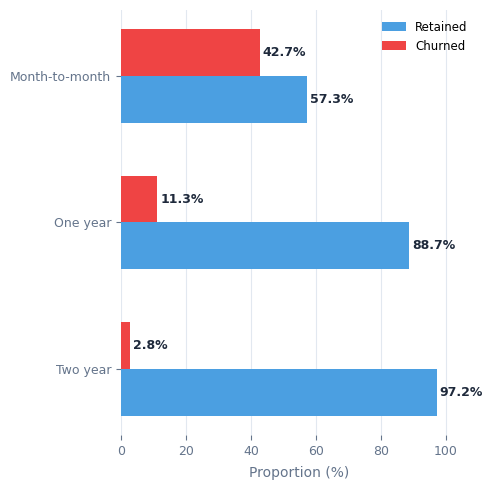

Saved Chart to - charts/09_bi_contract_churn.png


In [31]:
#Churn Rate by Contract Type
fig, ax = plt.subplots(figsize=(5, 5))

churn_rate = (eda_churn_df.groupby("contract")["churn"].value_counts(normalize=True).unstack().rename(
    columns={"No": "Retained", "Yes": "Churned"}).sort_values("Churned", ascending=True)) * 100

categories = churn_rate.index.tolist()
y = np.arange(len(categories))
height = 0.32

bars_ret = ax.barh(y - height/2, churn_rate["Retained"], height, color=ACCENT, zorder=3, edgecolor="none", label="Retained")
bars_chu = ax.barh(y + height/2, churn_rate["Churned"],  height, color=RED, zorder=3, edgecolor="none", label="Churned")

for bar in [*bars_ret, *bars_chu]:
    w = bar.get_width()
    ax.text(w + 1.0, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%", va="center", ha="left", fontsize=9, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Proportion (%)", ylabel="",grid_axis="x")

ax.set_yticks(y)
ax.set_yticklabels(categories, fontsize=9, color=MID_GRAY)
ax.set_xlim(0, 110)
ax.legend(fontsize=8.5, frameon=False, loc="upper right")

save(name="09_bi_contract_churn", show=True)

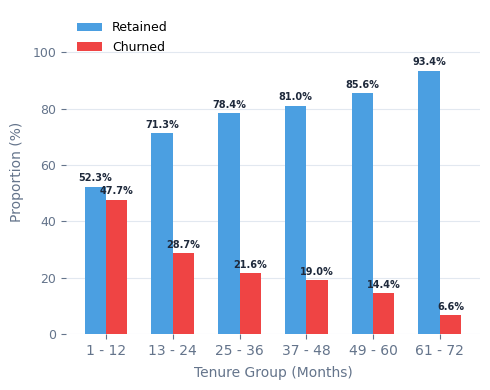

Saved Chart to - charts/10_bi_tenure_group_churn.png


In [32]:
#Churn Rate by Tenure Group (Months)
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = (eda_churn_df.groupby("tenure_group", observed=True)["churn"].value_counts(normalize=True).unstack().rename(columns={"No": "Retained", "Yes": "Churned"}).sort_values("Churned", ascending=False)) * 100

categories = churn_rate.index.tolist()
x = np.arange(len(categories))
width = 0.32

bars_ret = ax.bar(x - width/2, churn_rate["Retained"], width, color=ACCENT, zorder=3, edgecolor="none", label="Retained")
bars_chu = ax.bar(x + width/2, churn_rate["Churned"],  width, color=RED,    zorder=3, edgecolor="none", label="Churned")

for bar in [*bars_ret, *bars_chu]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1.2, f"{h:.1f}%", ha="center", va="bottom", fontsize=7, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Tenure Group (Months)", ylabel="Proportion (%)", grid_axis="y")

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, color=MID_GRAY)
ax.set_ylim(0, 115)
ax.legend(fontsize=9, frameon=False, loc="upper left")

save(name="10_bi_tenure_group_churn", show=True)

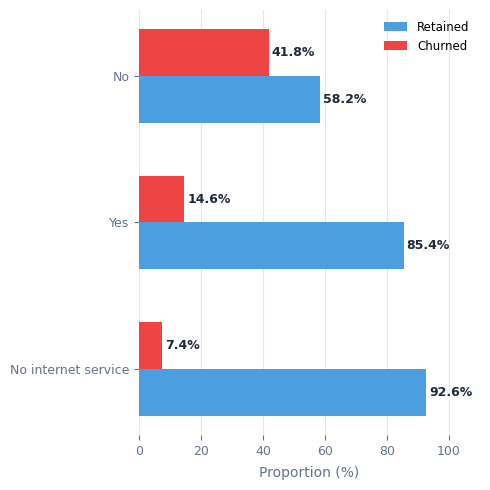

Saved Chart to - charts/11_bi_onlinesecurity_churn.png


In [33]:
#Churn Rate by Online Security
fig, ax = plt.subplots(figsize=(5, 5))

churn_rate = (eda_churn_df.groupby("onlinesecurity")["churn"].value_counts(normalize=True).unstack().rename(columns={"No": "Retained", "Yes": "Churned"}).sort_values("Churned", ascending=True)) * 100

categories = churn_rate.index.tolist()
y = np.arange(len(categories))
height = 0.32

bars_ret = ax.barh(y - height/2, churn_rate["Retained"], height, color=ACCENT, zorder=3, edgecolor="none", label="Retained")
bars_chu = ax.barh(y + height/2, churn_rate["Churned"], height,color=RED, zorder=3, edgecolor="none", label="Churned")

for bar in [*bars_ret, *bars_chu]:
    w = bar.get_width()
    ax.text(w + 1.0, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%", va="center", ha="left", fontsize=9, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Proportion (%)", ylabel="", grid_axis="x")

ax.set_yticks(y)
ax.set_yticklabels(categories, fontsize=9, color=MID_GRAY)
ax.set_xlim(0, 110)
ax.legend(fontsize=8.5, frameon=False, loc="upper right")

save(name="11_bi_onlinesecurity_churn", show=True)

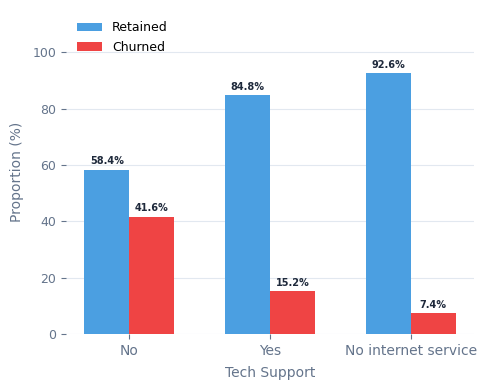

Saved Chart to - charts/12_bi_tenure_group_churn.png


In [34]:
#Churn Rate by Tech Support
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = (churn_df.groupby("techsupport", observed=True)["churn"].value_counts(normalize=True).unstack().rename(columns={"No": "Retained", "Yes": "Churned"}).sort_values("Churned", ascending=False)) * 100

categories = churn_rate.index.tolist()
x = np.arange(len(categories))
width = 0.32

bars_ret = ax.bar(x - width/2, churn_rate["Retained"], width, color=ACCENT, zorder=3, edgecolor="none", label="Retained")
bars_chu = ax.bar(x + width/2, churn_rate["Churned"],  width, color=RED, zorder=3, edgecolor="none", label="Churned")

for bar in [*bars_ret, *bars_chu]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1.2, f"{h:.1f}%", ha="center", va="bottom", fontsize=7, fontweight="bold", color=DARK_TEXT)

base_style(ax, title="", xlabel="Tech Support", ylabel="Proportion (%)", grid_axis="y")

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, color=MID_GRAY)
ax.set_ylim(0, 115)
ax.legend(fontsize=9, frameon=False, loc="upper left")

save(name="12_bi_tenure_group_churn", show=True)


In [35]:
# Numerical vs Categorical - t-test, Point Biserial Correlation
# https://numiqo.com/tutorial/point-biserial-correlation
result_bi_num_vs_cat = []
for col in eda_churn_df.select_dtypes(include={"float64"}).columns:
    group_yes = eda_churn_df[eda_churn_df['churn'] == 'Yes'][col]
    group_no  = eda_churn_df[eda_churn_df['churn'] == 'No'][col]
    
    t_stat, p_value = ttest_ind(group_yes, group_no, equal_var=False)  # Welch's T-test

    # Point Biserial Correlation
    n = len(eda_churn_df[col])
    n1 = len(group_yes)
    n2 = len(group_no)
    x1 = group_yes.mean()
    x2 =  group_no.mean()
    std_total = eda_churn_df[col].std()
    rpb = ((x1 - x2)/std_total)*np.sqrt((n1*n2)/n**2)

    if abs(rpb) >= 0.3:
        strength = "Strong"
    elif abs(rpb) >= 0.15:
        strength = "Moderate"
    elif abs(rpb) >= 0.05:
        strength = "Weak"
    else: 
        strength = "No Relationship"

    result_bi_num_vs_cat.append(
        {
            "Field": col,
            "T Test": round(t_stat, 2),
            "P Value": round(p_value, 6),
            "significant": "Yes" if p_value < 0.05 else "No",
            "Point Biserial": rpb,
            "Strength": strength
        }
    )
result_bi_num_vs_cat_df = pd.DataFrame(result_bi_num_vs_cat)
result_bi_num_vs_cat_df

,Field,T Test,P Value,significant,Point Biserial,Strength
0,monthlycharges,18.34,0.0,Yes,0.192845,Moderate
1,totalcharges,-18.80,0.0,Yes,-0.199470,Moderate


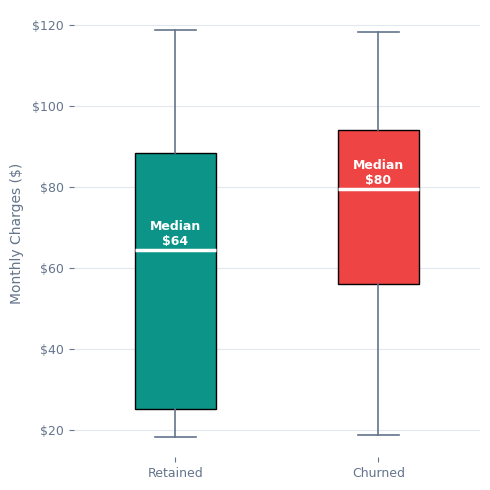

Saved Chart to - charts/13_bi_num_month_vs_churn.png


In [36]:
#Monthly Charges vs Churn
fig, ax = plt.subplots(figsize=(5, 5))
data_no  = eda_churn_df[eda_churn_df["churn"] == "No"]["monthlycharges"]
data_yes = eda_churn_df[eda_churn_df["churn"] == "Yes"]["monthlycharges"]

bp = ax.boxplot([data_no, data_yes], patch_artist=True, widths=0.4, medianprops=dict(color=WHITE, linewidth=2.5), whiskerprops=dict(color=MID_GRAY, linewidth=1.2), capprops=dict(color=MID_GRAY, linewidth=1.2), flierprops=dict(marker="o", color=MID_GRAY, alpha=0.3, markersize=3))

bp["boxes"][0].set_facecolor(TEAL)
bp["boxes"][1].set_facecolor(RED)

for i, (data, color) in enumerate([(data_no, TEAL), (data_yes, RED)], 1):
    median = data.median()
    ax.text(i, median + 0.5, f"Median\n${median:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color=WHITE)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Retained", "Churned"], fontsize=10, color=DARK_TEXT)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
base_style(ax, title="", ylabel="Monthly Charges ($)")
save(name="13_bi_num_month_vs_churn", show=True)

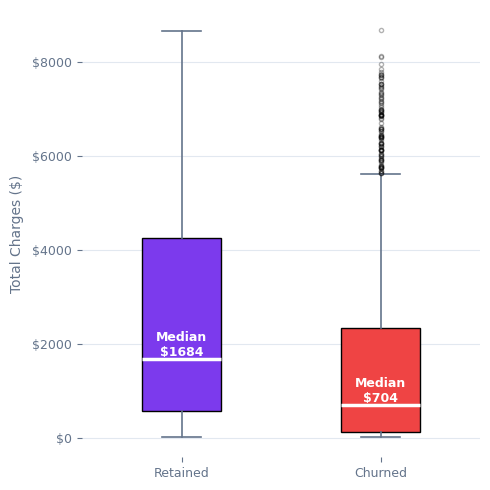

Saved Chart to - charts/14_bi_num_total_vs_churn.png


In [37]:
#Total Charges vs Churn
fig, ax = plt.subplots(figsize=(5, 5))
data_no  = eda_churn_df[eda_churn_df["churn"] == "No"]["totalcharges"]
data_yes = eda_churn_df[eda_churn_df["churn"] == "Yes"]["totalcharges"]

bp = ax.boxplot([data_no, data_yes], patch_artist=True, widths=0.4, medianprops=dict(color=WHITE, linewidth=2.5), whiskerprops=dict(color=MID_GRAY, linewidth=1.2), capprops=dict(color=MID_GRAY, linewidth=1.2), flierprops=dict(marker="o", color=MID_GRAY, alpha=0.3, markersize=3))

bp["boxes"][0].set_facecolor(PURPLE)
bp["boxes"][1].set_facecolor(RED)

for i, (data, color) in enumerate([(data_no, TEAL), (data_yes, RED)], 1):
    median = data.median()
    ax.text(i, median + 0.5, f"Median\n${median:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color=WHITE)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Retained", "Churned"], fontsize=10, color=DARK_TEXT)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}"))
base_style(ax, title="", ylabel="Total Charges ($)")
save(name="14_bi_num_total_vs_churn", show=True)

## Multivariate Analysis

- strongest columns from bivariate results 

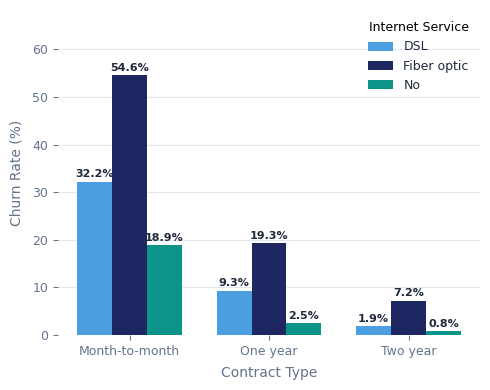

Saved Chart to - charts/15_multi_contract_internet_churn.png


In [38]:
#tenure_group and contract are more or less same thing
#Contract + InternetService + Churn

combo1 = churn_df.groupby(["contract", "internetservice"], observed=True)["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(1).unstack()

fig, ax = plt.subplots(figsize=(5, 4))

x = np.arange(len(combo1.index))
width = 0.25
bar_colors = [ACCENT, NAVY, TEAL]

for i, (col, color) in enumerate(zip(combo1.columns, bar_colors)):
    bars = ax.bar(x + i * width, combo1[col], width=width, color=color, label=col, zorder=3, edgecolor="none")
    for bar, val in zip(bars, combo1[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold", color=DARK_TEXT)

ax.set_xticks(x + width)
ax.set_xticklabels(combo1.index, fontsize=10, color=DARK_TEXT)
ax.legend(title="Internet Service", frameon=False, fontsize=9, labelcolor=DARK_TEXT, title_fontsize=9)
base_style(ax, title="", xlabel="Contract Type", ylabel="Churn Rate (%)")
ax.set_ylim(0, combo1.max().max() * 1.25)

save(name="15_multi_contract_internet_churn", show=True)

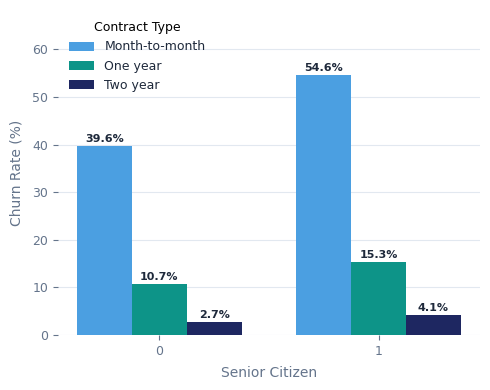

Saved Chart to - charts/16_multi_senior_contract_churn.png


In [39]:
# SeniorCitizen + Contract + Churn

fig, ax = plt.subplots(figsize=(5, 4))

combo2 = churn_df.groupby(["seniorcitizen", "contract"], observed=True)["churn"].apply(lambda x: (x == "Yes").mean() * 100).round(1).unstack()

x = np.arange(len(combo2.index))
width = 0.25
bar_colors = [ACCENT, TEAL, NAVY]

for i, (col, color) in enumerate(zip(combo2.columns, bar_colors)):
    bars = ax.bar(x + i * width, combo2[col], width=width, color=color, label=col, zorder=3, edgecolor="none")
    for bar, val in zip(bars, combo2[col]):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold", color=DARK_TEXT)

ax.set_xticks(x + width)
ax.set_xticklabels(combo2.index, fontsize=10, color=DARK_TEXT)
ax.legend(title="Contract Type", frameon=False, fontsize=9, labelcolor=DARK_TEXT, title_fontsize=9)
base_style(ax, title="", xlabel="Senior Citizen", ylabel="Churn Rate (%)")
ax.set_ylim(0, combo2.max().max() * 1.25)

save(name="16_multi_senior_contract_churn", show=True)

# ML Models

In [40]:
#base model
base_churn_df = churn_df.copy()
base_churn_df = base_churn_df.drop(columns=["customerid"])
# target encoding
base_churn_df["churn"] = (base_churn_df["churn"] == "Yes").astype(int)

In [41]:
base_churn_df.head(3)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [42]:
# feature = x, target = y
X = base_churn_df.drop(columns=["churn"])
y = base_churn_df["churn"]

In [43]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [44]:
models = {
    #Linear
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "SGD Classifier": SGDClassifier(),
    "Perceptron": Perceptron(),
    #Tree
    "Decision Tree": DecisionTreeClassifier(),
    "Extra Tree": ExtraTreeClassifier(),
    #Ensemble
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    #Neighbors
    "KNN": KNeighborsClassifier(),
    #SVM
    "SVC": SVC(probability=True),
    "Linear SVC": LinearSVC(),
    "Nu SVC": NuSVC(probability=True),
    #Naive Bayes
    "Gaussian NB": GaussianNB(),
    "Bernoulli NB": BernoulliNB(),
    #Discriminant Analysis
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    #Neural Net
    "MLP": MLPClassifier(max_iter=500),
    #Boosts
    "XGBoost":   XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
    "LightGBM":  LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost":  CatBoostClassifier(random_state=42, verbose=0),
    #Baseline
    "Dummy (majority)": DummyClassifier(strategy="most_frequent"),
    "Dummy (stratified)": DummyClassifier(strategy="stratified")
}

In [45]:
#train - 80% and test - 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
preprocessor_base_1 = ColumnTransformer(
    transformers= [("num", SimpleImputer(strategy="median"), num_cols),
                   ("cat", Pipeline([ ("impute", SimpleImputer(strategy="most_frequent")),
                                     ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols)])

In [47]:
#Num - (Median), Cat - (Mode, Ordinal)
base_results = []

for name, model in models.items():
    try:
        pipe = Pipeline([("preprocessor", preprocessor_base_1), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        elif hasattr(pipe, "decision_function"):
            y_score = pipe.decision_function(X_test)
        else:
            y_score = None
        auc = roc_auc_score(y_test, y_score) if y_score is not None else None
        base_results.append({
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "AUC-ROC": round(auc, 4) if auc else "N/A",
            "F1": round(f1_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "Status": "OK"
        })
    except Exception as e:
        base_results.append({
            "Model": model,
            "Accuracy": None,
            "AUC-ROC": None,
            "F1": None,
            "Precision": None,
            "Recall": None,
            "Status": f"Error: {e}"
            })
base_results_df = pd.DataFrame(base_results).sort_values("AUC-ROC", ascending=False)
base_results_df

,Model,Accuracy,AUC-ROC,F1,Precision,Recall,Status
8,Gradient Boosting,0.8013,0.8449,0.5745,0.6655,0.5053,OK
10,AdaBoost,0.7949,0.8432,0.5781,0.6367,0.5294,OK
14,Linear SVC,0.8034,0.8416,0.5968,0.6550,0.5481,OK
0,Logistic Regression,0.7977,0.8407,0.5923,0.6369,0.5535,OK
23,CatBoost,0.7921,0.8386,0.5646,0.6355,0.5080,OK
22,LightGBM,0.7970,0.8345,0.5806,0.6429,0.5294,OK
9,Hist Gradient Boosting,0.7949,0.8335,0.5806,0.6349,0.5348,OK
19,QDA,0.7559,0.8291,0.6186,0.5284,0.7460,OK
18,LDA,0.7864,0.8287,0.5694,0.6123,0.5321,OK
1,Ridge Classifier,0.7913,0.8287,0.5572,0.6379,0.4947,OK


In [48]:
preprocessor_base_2 = ColumnTransformer(
    transformers= [("num", SimpleImputer(strategy="median"), num_cols),
                   ("cat", Pipeline([ ("impute", SimpleImputer(strategy="most_frequent")),
                                     ("encode", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)])

In [49]:
#Num - (Median), Cat - (Mode, One Hot)
base_results = []

for name, model in models.items():
    try:
        pipe = Pipeline([("preprocessor", preprocessor_base_2), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        elif hasattr(pipe, "decision_function"):
            y_score = pipe.decision_function(X_test)
        else:
            y_score = None
        auc = roc_auc_score(y_test, y_score) if y_score is not None else None
        base_results.append({
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "AUC-ROC": round(auc, 4) if auc else "N/A",
            "F1": round(f1_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "Status": "OK"
        })
    except Exception as e:
        base_results.append({
            "Model": model,
            "Accuracy": None,
            "AUC-ROC": None,
            "F1": None,
            "Precision": None,
            "Recall": None,
            "Status": f"Error: {e}"
            })
base_results_df = pd.DataFrame(base_results).sort_values("AUC-ROC", ascending=False)
base_results_df

,Model,Accuracy,AUC-ROC,F1,Precision,Recall,Status
8,Gradient Boosting,0.8070,0.8435,0.5916,0.6747,0.5267,OK
10,AdaBoost,0.8020,0.8433,0.5939,0.6518,0.5455,OK
0,Logistic Regression,0.8041,0.8426,0.6023,0.6531,0.5588,OK
23,CatBoost,0.7928,0.8377,0.5718,0.6331,0.5214,OK
14,Linear SVC,0.7963,0.8369,0.5810,0.6399,0.5321,OK
9,Hist Gradient Boosting,0.7935,0.8346,0.5676,0.6388,0.5107,OK
22,LightGBM,0.7885,0.8323,0.5643,0.6226,0.5160,OK
1,Ridge Classifier,0.7956,0.8300,0.5765,0.6405,0.5241,OK
18,LDA,0.7857,0.8298,0.5734,0.6078,0.5428,OK
21,XGBoost,0.7850,0.8254,0.5726,0.6060,0.5428,OK


In [50]:
preprocessor_base_3 = ColumnTransformer(
    transformers= [("num", Pipeline([("impute", SimpleImputer(strategy="median")), 
                                     ("scale", StandardScaler())]), num_cols),
                   ("cat", Pipeline([ ("impute", SimpleImputer(strategy="most_frequent")),
                                     ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols)])

In [51]:
#Num - (Median, standardScalar), Cat - (Mode, Ordinal)
base_results = []

for name, model in models.items():
    try:
        pipe = Pipeline([("preprocessor", preprocessor_base_3), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        elif hasattr(pipe, "decision_function"):
            y_score = pipe.decision_function(X_test)
        else:
            y_score = None
        auc = roc_auc_score(y_test, y_score) if y_score is not None else None
        base_results.append({
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "AUC-ROC": round(auc, 4) if auc else "N/A",
            "F1": round(f1_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "Status": "OK"
        })
    except Exception as e:
        base_results.append({
            "Model": model,
            "Accuracy": None,
            "AUC-ROC": None,
            "F1": None,
            "Precision": None,
            "Recall": None,
            "Status": f"Error: {e}"
            })
base_results_df = pd.DataFrame(base_results).sort_values("AUC-ROC", ascending=False)
base_results_df

,Model,Accuracy,AUC-ROC,F1,Precision,Recall,Status
8,Gradient Boosting,0.8020,0.8450,0.5766,0.6667,0.5080,OK
10,AdaBoost,0.7949,0.8432,0.5781,0.6367,0.5294,OK
0,Logistic Regression,0.8006,0.8403,0.5933,0.6467,0.5481,OK
23,CatBoost,0.7921,0.8386,0.5646,0.6355,0.5080,OK
14,Linear SVC,0.7942,0.8356,0.5748,0.6364,0.5241,OK
22,LightGBM,0.7935,0.8341,0.5689,0.6379,0.5134,OK
9,Hist Gradient Boosting,0.7949,0.8335,0.5806,0.6349,0.5348,OK
19,QDA,0.7559,0.8291,0.6186,0.5284,0.7460,OK
2,SGD Classifier,0.7899,0.8288,0.5179,0.6625,0.4251,OK
1,Ridge Classifier,0.7913,0.8287,0.5572,0.6379,0.4947,OK


In [52]:
preprocessor_base_4 = ColumnTransformer(
    transformers= [("num", Pipeline([("impute", SimpleImputer(strategy="median")), 
                                     ("scale", StandardScaler())]), num_cols),
                   ("cat", Pipeline([ ("impute", SimpleImputer(strategy="most_frequent")),
                                     ("encode", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)])

In [53]:
#Num - (Median, standardScalar), Cat - (Mode, One Hot)
base_results = []

for name, model in models.items():
    try:
        pipe = Pipeline([("preprocessor", preprocessor_base_4), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        elif hasattr(pipe, "decision_function"):
            y_score = pipe.decision_function(X_test)
        else:
            y_score = None
        auc = roc_auc_score(y_test, y_score) if y_score is not None else None
        base_results.append({
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "AUC-ROC": round(auc, 4) if auc else "N/A",
            "F1": round(f1_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "Status": "OK"
        })
    except Exception as e:
        base_results.append({
            "Model": model,
            "Accuracy": None,
            "AUC-ROC": None,
            "F1": None,
            "Precision": None,
            "Recall": None,
            "Status": f"Error: {e}"
            })
base_results_df = pd.DataFrame(base_results).sort_values("AUC-ROC", ascending=False)
base_results_df

,Model,Accuracy,AUC-ROC,F1,Precision,Recall,Status
8,Gradient Boosting,0.8062,0.8434,0.5895,0.6735,0.5241,OK
10,AdaBoost,0.8020,0.8433,0.5939,0.6518,0.5455,OK
0,Logistic Regression,0.8055,0.8419,0.6040,0.6572,0.5588,OK
23,CatBoost,0.7928,0.8377,0.5718,0.6331,0.5214,OK
14,Linear SVC,0.8006,0.8358,0.5910,0.6486,0.5428,OK
9,Hist Gradient Boosting,0.7935,0.8345,0.5676,0.6388,0.5107,OK
22,LightGBM,0.7892,0.8316,0.5702,0.6215,0.5267,OK
1,Ridge Classifier,0.7949,0.8301,0.5744,0.6393,0.5214,OK
18,LDA,0.7857,0.8298,0.5734,0.6078,0.5428,OK
21,XGBoost,0.7850,0.8254,0.5726,0.6060,0.5428,OK


In [54]:
# top 5 models

preprocessor_base_5 = ColumnTransformer(
    transformers= [("num", Pipeline([("impute", SimpleImputer(strategy="median")), 
                                     ("scale", StandardScaler())]), num_cols),
                   ("cat", Pipeline([ ("impute", SimpleImputer(strategy="most_frequent")),
                                     ("encode", OneHotEncoder(handle_unknown="ignore", 
                                        sparse_output=False))]), cat_cols)])

In [55]:
top5 = {
    "Gradient Boosting": GradientBoostingClassifier(random_state=4),
    "AdaBoost": AdaBoostClassifier(random_state=4),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=4),
    "CatBoost":  CatBoostClassifier(random_state=4, verbose=0),
    "LinearSVC": LinearSVC(random_state=4)
}

In [56]:
results = []

for strategy in ["baseline", "balanced", "smote"]:
    for name, model in top5.items():
        if strategy == "balanced" and hasattr(model, "class_weight"):
            model.set_params(class_weight="balanced")
        if strategy == "smote":
            pipe = ImbPipeline([
                ("preprocessor", preprocessor_base_5),
                ("smote", SMOTE(random_state=42)),
                ("model", model)
            ])
        else:
            pipe = ImbPipeline([
                ("preprocessor", preprocessor_base_5),
                ("model", model)
            ])
        try:
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            if hasattr(pipe, "predict_proba"):
                y_score = pipe.predict_proba(X_test)[:, 1]
            elif hasattr(pipe, "decision_function"):
                y_score = pipe.decision_function(X_test)
            else:
                y_score = None
            auc = roc_auc_score(y_test, y_score) if y_score is not None else None
            results.append({
                "Strategy": strategy,
                "Model": name,
                "Accuracy": round(accuracy_score(y_test, y_pred), 4),
                "AUC-ROC": round(auc, 4) if auc else "N/A",
                "F1": round(f1_score(y_test, y_pred), 4),
                "Precision": round(precision_score(y_test, y_pred), 4),
                "Recall": round(recall_score(y_test, y_pred), 4),
                "Status": "OK"
            })
        except Exception as e:
            results.append({
                "Strategy":  strategy,
                "Model": model,
                "Accuracy": None,
                "AUC-ROC": None,
                "F1": None,
                "Precision": None,
                "Recall": None,
                "Status": f"Error: {e}"
                })
results_df = pd.DataFrame(results).sort_values(["Model", "AUC-ROC"], ascending=[True, False])
results_df

,Strategy,Model,Accuracy,AUC-ROC,F1,Precision,Recall,Status
1,baseline,AdaBoost,0.8020,0.8433,0.5939,0.6518,0.5455,OK
6,balanced,AdaBoost,0.8020,0.8433,0.5939,0.6518,0.5455,OK
11,smote,AdaBoost,0.7502,0.8394,0.6199,0.5199,0.7674,OK
3,baseline,CatBoost,0.7949,0.8383,0.5769,0.6375,0.5267,OK
8,balanced,CatBoost,0.7949,0.8383,0.5769,0.6375,0.5267,OK
13,smote,CatBoost,0.7736,0.8326,0.5808,0.5711,0.5909,OK
0,baseline,Gradient Boosting,0.8062,0.8434,0.5895,0.6735,0.5241,OK
5,balanced,Gradient Boosting,0.8062,0.8434,0.5895,0.6735,0.5241,OK
10,smote,Gradient Boosting,0.7743,0.8401,0.6159,0.5617,0.6818,OK
9,balanced,LinearSVC,0.7381,0.8386,0.6152,0.5043,0.7888,OK


In [57]:
# as recall is more as missing a churner costs more than a false alarm.
# based on f1 and auc -> SMOTE + AdaBoost and SMOTE + Logistic Regression
results_df = pd.DataFrame(results).sort_values(["F1"], ascending=[False])
results_df

,Strategy,Model,Accuracy,AUC-ROC,F1,Precision,Recall,Status
11,smote,AdaBoost,0.7502,0.8394,0.6199,0.5199,0.7674,OK
12,smote,Logistic Regression,0.7374,0.8400,0.6162,0.5034,0.7941,OK
10,smote,Gradient Boosting,0.7743,0.8401,0.6159,0.5617,0.6818,OK
9,balanced,LinearSVC,0.7381,0.8386,0.6152,0.5043,0.7888,OK
14,smote,LinearSVC,0.7381,0.8375,0.6152,0.5043,0.7888,OK
7,balanced,Logistic Regression,0.7381,0.8413,0.6136,0.5043,0.7834,OK
2,baseline,Logistic Regression,0.8055,0.8419,0.6040,0.6572,0.5588,OK
6,balanced,AdaBoost,0.8020,0.8433,0.5939,0.6518,0.5455,OK
1,baseline,AdaBoost,0.8020,0.8433,0.5939,0.6518,0.5455,OK
4,baseline,LinearSVC,0.8006,0.8358,0.5910,0.6486,0.5428,OK


In [58]:
# Hyperparameter tuning

tuning_configs = {
    "SMOTE + Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, random_state=42),
        "params": {
            "model__C":           uniform(0.01, 10),
            "model__penalty":     ["l1", "l2", "elasticnet"],
            "model__solver":      ["saga"],
            "model__l1_ratio":    uniform(0, 1),
            "model__class_weight": [None, "balanced"],
        }
    },
    "SMOTE + AdaBoost": {
        "model": AdaBoostClassifier(random_state=42),
        "params": {
            "model__n_estimators":   randint(50, 500),
            "model__learning_rate":  uniform(0.01, 2.0)
        }
    },
}

In [59]:
tuning_results = {}

for name, config in tuning_configs.items():
    print(f"\nTuning: {name}")
    pipe = ImbPipeline([
        ("preprocessor", preprocessor_base_5), 
        ("smote", SMOTE(random_state=42)), 
        ("model", config["model"])
    ])
    search = RandomizedSearchCV(estimator=pipe, param_distributions=config["params"], n_iter=50, scoring="recall", cv=5, random_state=42, n_jobs=-1, verbose=1, refit=True )
    search.fit(X_train, y_train)
    y_pred  = search.best_estimator_.predict(X_test)
    if hasattr(search.best_estimator_, "predict_proba"):
        y_score = search.best_estimator_.predict_proba(X_test)[:, 1]
    elif hasattr(search.best_estimator_, "decision_function"):
        y_score = search.best_estimator_.decision_function(X_test)
    else:
        y_score = None

    tuning_results[name] = {
        "best_params": search.best_params_,
        "best_estimator": search.best_estimator_,
        "cv_recall": round(search.best_score_, 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_score), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
    }

    print(f"Best CV Recall: {tuning_results[name]['cv_recall']}")
    print(f"Test Recall: {tuning_results[name]['Recall']}")
    print(f"Test AUC-ROC: {tuning_results[name]['AUC-ROC']}")
    print(f"Best Params: {search.best_params_}")
    # print(f"Best Estimator: {search.best_estimator_}")


Tuning: SMOTE + Logistic Regression
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV Recall: 0.7993
Test Recall: 0.7941
Test AUC-ROC: 0.8395
Best Params: {'model__C': np.float64(4.602488919658671), 'model__class_weight': None, 'model__l1_ratio': np.float64(0.6011150117432088), 'model__penalty': 'elasticnet', 'model__solver': 'saga'}

Tuning: SMOTE + AdaBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV Recall: 0.8187
Test Recall: 0.8048
Test AUC-ROC: 0.8238
Best Params: {'model__learning_rate': np.float64(0.03652992231973306), 'model__n_estimators': 138}


In [60]:
tuning_results_df = pd.DataFrame([
    {
        "Model":     name,
        "CV Recall": v["cv_recall"],
        "Accuracy":  v["Accuracy"],
        "AUC-ROC":   v["AUC-ROC"],
        "F1":        v["F1"],
        "Precision": v["Precision"],
        "Recall":    v["Recall"],
    }
    for name, v in tuning_results.items()]).sort_values("Recall", ascending=False)

In [61]:
tuning_results_df

,Model,CV Recall,Accuracy,AUC-ROC,F1,Precision,Recall
1,SMOTE + AdaBoost,0.8187,0.7026,0.8238,0.5896,0.4652,0.8048
0,SMOTE + Logistic Regression,0.7993,0.7374,0.8395,0.6162,0.5034,0.7941


In [62]:
#used chatgpt to generate this code using above one
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    cat_features  = (preprocessor
                     .named_transformers_["cat"]
                     .named_steps["encode"]
                     .get_feature_names_out(cat_cols)
                     .tolist())
    return num_cols + cat_features

tuning_results_top20 = {}

for name, result in tuning_results.items():
    print(f"\n{'='*50}")
    print(f"SHAP — {name}")
    print('='*50)

    best_pipe  = result["best_estimator"]
    model_step = best_pipe.named_steps["model"]
    feat_names = get_feature_names(best_pipe)

    X_test_transformed = best_pipe.named_steps["preprocessor"].transform(X_test)
    X_test_df = pd.DataFrame(X_test_transformed, columns=feat_names)

    if isinstance(model_step, LogisticRegression):
        explainer = shap.LinearExplainer(model_step, X_test_df)
        shap_vals = explainer.shap_values(X_test_df)
        X_shap    = X_test_df

    elif isinstance(model_step, AdaBoostClassifier):
        X_sample  = shap.sample(X_test_df, 200, random_state=42)
        explainer = shap.KernelExplainer(model_step.predict_proba, X_sample)
        raw_shap  = explainer.shap_values(X_sample, nsamples=100)
        shap_vals = np.array(raw_shap)[:, :, 1]  # (200, 45)
        X_shap    = X_sample

    shap_importance = (
        pd.DataFrame({
            "Feature":  X_shap.columns.tolist(),
            "Mean |SHAP|": np.abs(shap_vals).mean(axis=0)
        })
        .sort_values("Mean |SHAP|", ascending=False)
        .reset_index(drop=True)
    )
    print(shap_importance.to_string(index=False))

    top20_features = shap_importance["Feature"].head(20).tolist()
    print(f"\nTop 20 features for {name}:")
    print(top20_features)

    X_train_transformed = best_pipe.named_steps["preprocessor"].transform(X_train)
    X_train_full_df = pd.DataFrame(X_train_transformed, columns=feat_names)

    X_train_top20 = X_train_full_df[top20_features]
    X_test_top20  = X_test_df[top20_features]

    print(f"\nRetuning {name} with top 20 features...")

    if isinstance(model_step, LogisticRegression):
        model_retune = LogisticRegression(max_iter=2000, random_state=42)
        param_dist   = {
            "model__C": uniform(0.01, 10),
            "model__penalty": ["l1", "l2", "elasticnet"],
            "model__solver": ["saga"],
            "model__l1_ratio": uniform(0, 1),
            "model__class_weight": [None, "balanced"],
        }
    elif isinstance(model_step, AdaBoostClassifier):
        model_retune = AdaBoostClassifier(random_state=42)
        param_dist   = {
            "model__n_estimators":  randint(50, 500),
            "model__learning_rate": uniform(0.01, 2.0),
        }

    pipe_top20 = ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", model_retune)
    ])

    search_top20 = RandomizedSearchCV(
        estimator=pipe_top20,
        param_distributions=param_dist,
        n_iter=50,
        scoring="recall",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search_top20.fit(X_train_top20, y_train)

    y_pred  = search_top20.best_estimator_.predict(X_test_top20)
    if hasattr(search.best_estimator_, "predict_proba"):
        y_score = search.best_estimator_.predict_proba(X_test)[:, 1]
    elif hasattr(search.best_estimator_, "decision_function"):
        y_score = search.best_estimator_.decision_function(X_test)
    else:
        y_score = None

    tuning_results_top20[name] = {
        "top20_features": top20_features,
        "best_params": search_top20.best_params_,
        "best_estimator": search_top20.best_estimator_,
        "cv_recall": round(search_top20.best_score_, 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_test, y_score), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
    }

    print(f"\nCV Recall: {tuning_results_top20[name]['cv_recall']}")
    print(f"Test Recall: {tuning_results_top20[name]['Recall']}")
    print(f"AUC-ROC: {tuning_results_top20[name]['AUC-ROC']}")
    print(f"Best Params: {search_top20.best_params_}")

print("\nFull features vs Top 20 features comparison:")

comparison = []
for name in tuning_results:
    comparison.append({
        "Model":          name,
        "Features":       "All",
        "CV Recall":      tuning_results[name]["cv_recall"],
        "Accuracy":       tuning_results[name]["Accuracy"],
        "AUC-ROC":        tuning_results[name]["AUC-ROC"],
        "F1":             tuning_results[name]["F1"],
        "Precision":      tuning_results[name]["Precision"],
        "Recall":         tuning_results[name]["Recall"],
    })
    comparison.append({
        "Model":          name,
        "Features":       "Top 20",
        "CV Recall":      tuning_results_top20[name]["cv_recall"],
        "Accuracy":       tuning_results_top20[name]["Accuracy"],
        "AUC-ROC":        tuning_results_top20[name]["AUC-ROC"],
        "F1":             tuning_results_top20[name]["F1"],
        "Precision":      tuning_results_top20[name]["Precision"],
        "Recall":         tuning_results_top20[name]["Recall"],
    })

comparison_df = pd.DataFrame(comparison).sort_values(
    ["Model", "Recall"], ascending=[True, False]
)
comparison_df


SHAP — SMOTE + Logistic Regression
                                Feature  Mean |SHAP|
                         monthlycharges     1.236038
                                 tenure     1.219427
            internetservice_Fiber optic     0.837041
                           totalcharges     0.582962
                contract_Month-to-month     0.394845
                    streamingmovies_Yes     0.345081
                        streamingtv_Yes     0.293850
                      multiplelines_Yes     0.240135
                      contract_Two year     0.233794
         paymentmethod_Electronic check     0.166909
                    paperlessbilling_No     0.147484
                      onlinesecurity_No     0.132678
                         dependents_Yes     0.109798
                         techsupport_No     0.090177
        streamingtv_No internet service     0.081145
        techsupport_No internet service     0.081145
    streamingmovies_No internet service     0.081145
     onlin

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



CV Recall: 0.8047
Test Recall: 0.7914
AUC-ROC: 0.8238
Best Params: {'model__C': np.float64(0.32313292455558584), 'model__class_weight': 'balanced', 'model__l1_ratio': np.float64(0.7751328233611146), 'model__penalty': 'l2', 'model__solver': 'saga'}

SHAP — SMOTE + AdaBoost


  0%|          | 0/200 [00:00<?, ?it/s]

                                Feature  Mean |SHAP|
                contract_Month-to-month     0.131386
                      onlinesecurity_No     0.050181
         paymentmethod_Electronic check     0.034233
            internetservice_Fiber optic     0.029916
                      contract_Two year     0.026164
                         techsupport_No     0.018144
                                 tenure     0.013833
                    paperlessbilling_No     0.000841
                   paperlessbilling_Yes     0.000608
                         dependents_Yes     0.000396
                     internetservice_No     0.000381
                            partner_Yes     0.000351
                     streamingmovies_No     0.000328
                   deviceprotection_Yes     0.000324
                             partner_No     0.000307
                        phoneservice_No     0.000306
                    deviceprotection_No     0.000289
   deviceprotection_No internet service     0.

,Model,Features,CV Recall,Accuracy,AUC-ROC,F1,Precision,Recall
3,SMOTE + AdaBoost,Top 20,0.8194,0.7048,0.8238,0.5922,0.4675,0.8075
2,SMOTE + AdaBoost,All,0.8187,0.7026,0.8238,0.5896,0.4652,0.8048
0,SMOTE + Logistic Regression,All,0.7993,0.7374,0.8395,0.6162,0.5034,0.7941
1,SMOTE + Logistic Regression,Top 20,0.8047,0.7360,0.8238,0.6141,0.5017,0.7914


In [63]:
ada_params = {
    "model__n_estimators" : [50, 100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

top_20_features = ["num__monthlycharges", "num__totalcharges", "num__tenure", 
                           "cat__internetservice_Fiber optic", "cat__contract_Month-to-month", 
                           "cat__contract_Two year", "cat__streamingmovies_Yes", "cat__streamingtv_Yes", "cat__multiplelines_Yes", "cat__paymentmethod_Electronic check", "cat__paperlessbilling_No", "cat__onlinesecurity_No", "cat__dependents_Yes", "cat__techsupport_No", "cat__streamingtv_No internet service", "cat__techsupport_No internet service", "cat__streamingmovies_No internet service", "cat__onlinesecurity_No internet service", "cat__deviceprotection_No internet service", 
                           "cat__onlinebackup_No internet service"]

preprocessor_base_5.fit(X_train, y_train)
encoded_cols = preprocessor_base_5.get_feature_names_out()
X_train_Smote = pd.DataFrame(preprocessor_base_5.transform(X_train), columns=encoded_cols)
X_test_Smote = pd.DataFrame(preprocessor_base_5.transform(X_test), columns=encoded_cols)

ada_pipeline = ImbPipeline([("smote", SMOTE(random_state=42)), 
                            ("model", AdaBoostClassifier(random_state=42))])

ada_grid = GridSearchCV( ada_pipeline, ada_params, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1)

ada_grid.fit(X_train_Smote[top_20_features], y_train)

print(f"Best Params : {ada_grid.best_params_}")
print(f"Best CV Recall : {ada_grid.best_score_:.4f}")

# Evaluate on test set
best_ada = ada_grid.best_estimator_
y_pred   = best_ada.predict(X_test_Smote[top_20_features])
y_prob   = best_ada.predict_proba(X_test_Smote[top_20_features])[:, 1]

print(f"\nTest Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Test F1: {f1_score(y_test, y_pred):.4f}")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params : {'model__learning_rate': 1.0, 'model__n_estimators': 200}
Best CV Recall : 0.8480

Test Recall: 0.7727
Test F1: 0.6208
Test AUC-ROC: 0.8403


# Save Model

In [64]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_ada, "models/adaboost_churn_model.pkl")
joblib.dump(preprocessor_base_5, "models/preprocessor.pkl")
joblib.dump(top_20_features, "models/top20_features.pkl")

['models/top20_features.pkl']

In [ ]:
#verify
loaded_model = joblib.load("models/adaboost_churn_model.pkl")
loaded_preprocessor = joblib.load("models/preprocessor.pkl")
loaded_features = joblib.load("models/top20_features.pkl")

sample_customers = X_test.iloc[:5].reset_index(drop=True)

encoded = loaded_preprocessor.transform(sample_customers)
encoded_df = pd.DataFrame(encoded, columns=loaded_preprocessor.get_feature_names_out())
proba = loaded_model.predict_proba(encoded_df[loaded_features])[:, 1]

proba

array([0.34508197, 0.56761486, 0.39957983, 0.49569258, 0.32588612])